In [1]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
print(tf.__version__)

2.9.1


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Scale pixel values to [0, 1]
    rotation_range=20,  # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,  # Randomly shift the width of the image
    height_shift_range=0.2,  # Randomly shift the height of the image
    horizontal_flip=True,  # Randomly flip images horizontally
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Randomly zoom into images
    fill_mode="nearest"  # Fill in missing pixels using the nearest neighbor
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Scale pixel values to [0, 1]
    rotation_range=20,  # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,  # Randomly shift the width of the image
    height_shift_range=0.2,  # Randomly shift the height of the image
    horizontal_flip=True,  # Randomly flip images horizontally
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Randomly zoom into images
    fill_mode="nearest"  # Fill in missing pixels using the nearest neighbor
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(224, 224),  # Resize images to a specific size
    batch_size=8,  # Set the batch size based on your hardware capabilities
    class_mode='categorical',  # Specify the type of classification task
    shuffle=True  # Shuffle the data for better training
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False  # Don't shuffle the test data
)

val_generator = val_datagen.flow_from_directory(
    'val',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=True  # Don't shuffle the test data
)

Found 286 images belonging to 3 classes.
Found 85 images belonging to 3 classes.
Found 43 images belonging to 3 classes.


In [5]:
model = tf.keras.Sequential([
    # Block 1
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(224, 224, 3), padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Block 3
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Block 4
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Block 5
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Flatten and fully connected layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes (healthy, caterpillar, leafspot)
])

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 64)      1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 112, 112, 128)     147584    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 128)      0         
 2D)                                                    

In [8]:
# Compile and fit your model using Model.fit
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs=24, validation_data=val_generator)

Epoch 1/24
36/36 [==============================] - 168s 5s/step - loss: 1.1720 - accuracy: 0.3392 - val_loss: 1.0898 - val_accuracy: 0.3953
Epoch 2/24
36/36 [==============================] - 154s 4s/step - loss: 1.0933 - accuracy: 0.4021 - val_loss: 1.0903 - val_accuracy: 0.3953
Epoch 3/24
36/36 [==============================] - 164s 5s/step - loss: 1.0950 - accuracy: 0.4021 - val_loss: 1.0903 - val_accuracy: 0.3953
Epoch 4/24
36/36 [==============================] - 162s 5s/step - loss: 1.0891 - accuracy: 0.4021 - val_loss: 1.0888 - val_accuracy: 0.3953
Epoch 5/24
36/36 [==============================] - 180s 5s/step - loss: 1.0917 - accuracy: 0.4021 - val_loss: 1.0886 - val_accuracy: 0.3953
Epoch 6/24
36/36 [==============================] - 179s 5s/step - loss: 1.0914 - accuracy: 0.4021 - val_loss: 1.0898 - val_accuracy: 0.3953
Epoch 7/24
36/36 [==============================] - 184s 5s/step - loss: 1.0887 - accuracy: 0.4021 - val_loss: 1.0890 - val_accuracy: 0.3953
Epoch 8/24
 1

KeyboardInterrupt: 

In [ ]:
# # Create a model checkpoint callback
# checkpoint = tf.keras.callbacks.ModelCheckpoint("vgg16_1.h5", monitor='accuracy', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')

# # Create an early stopping callback
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='accuracy', min_delta=0, patience=20, verbose=2, mode='auto')

# # Compile and fit your model using Model.fit
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# history = model.fit(train_generator, steps_per_epoch=8, validation_data=val_generator, validation_steps=10, epochs=100, callbacks=[checkpoint, early_stopping])


In [ ]:
# plt.plot(hist.history["accuracy"])
# plt.plot(hist.history['val_accuracy'])
# plt.plot(hist.history['loss'])
# plt.plot(hist.history['val_loss'])
# plt.title("model accuracy")
# plt.ylabel("Accuracy")
# plt.xlabel("Epoch")
# plt.legend(["Accuracy","Validation Accuracy","loss","Validation Loss"])
# plt.show()

11/11 [==============================] - 22s 2s/step
Classification Report:
              precision    recall  f1-score   support

 caterpiller       0.39      1.00      0.56        33
     healthy       0.00      0.00      0.00        28
    leafspot       0.00      0.00      0.00        24

    accuracy                           0.39        85
   macro avg       0.13      0.33      0.19        85
weighted avg       0.15      0.39      0.22        85



c:\Users\SAnuv\anaconda3\envs\tensorflow\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\SAnuv\anaconda3\envs\tensorflow\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\SAnuv\anaconda3\envs\tensorflow\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


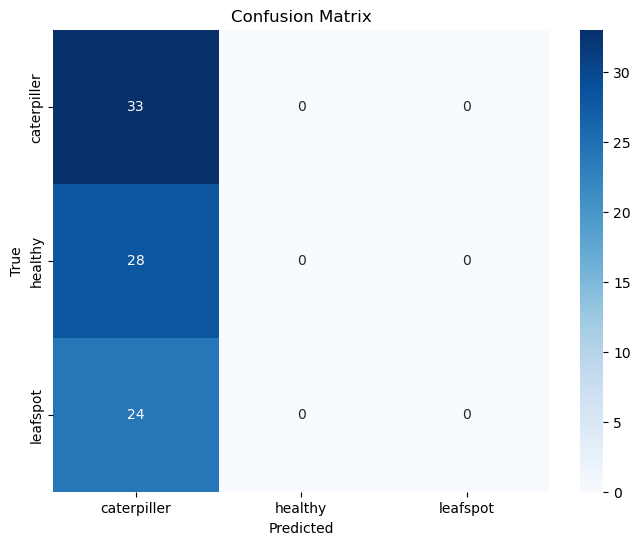

In [9]:
# Evaluate the model on the test data
test_results = model.evaluate(test_generator)

# Make predictions on the test data
y_pred = model.predict(test_generator)
# Convert one-hot encoded labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the actual class labels from the test generator
y_true = test_generator.classes

# Generate the classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices)

print("Classification Report:")
print(class_report)

# Generate the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()